# Chapter 5 — Exercise 2

This exercise investigates the probability that a particular observation
from the original data set appears in a bootstrap sample.

## (a)

There are \(n\) observations in the original sample.

The probability that the first bootstrap observation is the \(j\)th observation is:

\[
\frac{1}{n}
\]

Therefore, the probability that it is **not** the \(j\)th observation is:

\[
\boxed{1-\frac{1}{n}}
\]


## (b)

Because bootstrap observations are sampled independently with replacement,
the probability that the second bootstrap observation is not the
\(j\)th observation is also:

\[
\boxed{1-\frac{1}{n}}
\]


## (c)

A bootstrap sample contains \(n\) draws.

The probability of not selecting the \(j\)th observation on one draw is:

\[
1-\frac{1}{n}
\]

Therefore, the probability of not selecting it on all \(n\) draws is:

\[
\boxed{\left(1-\frac{1}{n}\right)^n}
\]

In [29]:
1 - (1 - 1/5)**5

0.6723199999999999

## (d)

For \(n=5\):

\[
P(\text{observation included})
=
1-\left(1-\frac{1}{5}\right)^5
\]

\[
=1-\left(\frac{4}{5}\right)^5
\]

\[
\boxed{0.67232}
\]

Therefore, the probability is approximately **67.23%**.

In [30]:
1 - (1 - 1/100)**100

0.6339676587267709

## (e)

For \(n=100\):

\[
P(\text{observation included})
=
1-\left(1-\frac{1}{100}\right)^{100}
\]

\[
\boxed{\approx 0.634}
\]

Therefore, the probability is approximately **63.4%**.

In [31]:
1 - (1 - 1/10000)**10000

0.6321389535670295

## (f)

For \(n=10{,}000\):

\[
P(\text{observation included})
=
1-\left(1-\frac{1}{10000}\right)^{10000}
\]

\[
\boxed{\approx 0.6321}
\]

Therefore, the probability is approximately **63.21%**.

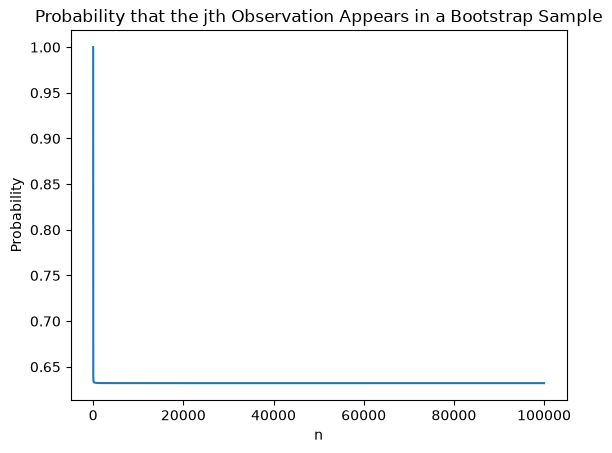

In [32]:
#2(g)
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 100001)

probability = 1 - (1 - 1/n)**n

fig, ax = plt.subplots()

ax.plot(n, probability)

ax.set_xlabel('n')
ax.set_ylabel('Probability')
ax.set_title('Probability that the jth Observation Appears in a Bootstrap Sample')

plt.show()

## (g)

The probability decreases quickly for small values of \(n\), and then
approaches a value close to:

\[
0.632
\]

as \(n\) becomes large.

Therefore, for a large bootstrap sample, a particular original observation
has approximately a **63.2% probability** of appearing at least once in the
bootstrap sample.

In [33]:
rng = np.random.default_rng(10)

store = np.empty(10000)

for i in range(10000):
    store[i] = np.sum(
        rng.choice(100, size=100, replace=True) == 4
    ) > 0

np.mean(store)

np.float64(0.6362)

## (h)

The simulation gives a probability of approximately:

\[
\boxed{0.636}
\]

This is very close to the theoretical probability obtained in part (e):

\[
0.634
\]

Therefore, the simulation supports the theoretical result that a particular
observation has roughly a **63% chance** of appearing at least once in a
bootstrap sample of size \(n\).

In [34]:
from ISLP import load_data

#Exercise 7(a)
Weekly = load_data('Weekly')

import statsmodels.api as sm

X = sm.add_constant(Weekly[['Lag1', 'Lag2']])
y = (Weekly['Direction'] == 'Up').astype(int)

glm = sm.GLM(
    y,
    X,
    family=sm.families.Binomial()
)

results = glm.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Thu, 27 Aug 2026   Deviance:                       1488.2
Time:                        13:46:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.000       0.101       0.342
Lag1          -0.0387      0.026     -1.477      0.140      -0.090       0.013
Lag2           0.0602      0.027      2.270      0.023       0.008       0.112
==============================================================================
"""

## Chapter 5 — Exercise 7

### (a)

A logistic regression model was fitted using `Lag1` and `Lag2` to predict
the market direction.

The response was coded as:

- `1` = Up
- `0` = Down

In [35]:
#Exercise 7(b)
X_train = X.iloc[1:]
y_train = y.iloc[1:]

glm_minus_first = sm.GLM(
    y_train,
    X_train,
    family=sm.families.Binomial()
)

results_minus_first = glm_minus_first.fit()

results_minus_first.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Direction   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Thu, 27 Aug 2026   Deviance:                       1486.5
Time:                        13:46:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.000       0.103       0.344
Lag1          -0.0384      0.026     -1.466      0.143      -0.090       0.013
Lag2           0.0608      0.027      2.291      0.022       0.009       0.113
==============================================================================
"""

In [36]:
#Exercise 7(c)
prob_first = results_minus_first.predict(
    X.iloc[[0]]
).iloc[0]

pred_first = 'Up' if prob_first > 0.5 else 'Down'

actual_first = Weekly['Direction'].iloc[0]

print("Probability of Up:", prob_first)
print("Predicted Direction:", pred_first)
print("Actual Direction:", actual_first)
print("Correctly classified:", pred_first == actual_first)

Probability of Up: 0.571392320520443
Predicted Direction: Up
Actual Direction: Down
Correctly classified: False


In [37]:
#Exercise 7(d)
n = Weekly.shape[0]

errors = np.zeros(n)

for i in range(n):

    X_train = X.drop(X.index[i])
    y_train = y.drop(y.index[i])

    glm_i = sm.GLM(
        y_train,
        X_train,
        family=sm.families.Binomial()
    )

    results_i = glm_i.fit()

    prob_i = results_i.predict(
        X.iloc[[i]]
    ).iloc[0]

    pred_i = 1 if prob_i > 0.5 else 0

    errors[i] = int(pred_i != y.iloc[i])

In [38]:
errors[:20]

array([1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1.,
       0., 1., 0.])

In [39]:
loocv_error = np.mean(errors)

loocv_error

np.float64(0.44995408631772266)

In [40]:
1 - loocv_error

np.float64(0.5500459136822773)